# Davis2017

[https://doi.org/10.1098/rstb.2016.0381](https://doi.org/10.1098/rstb.2016.0381)

In [225]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from mxlpy import Simulator, make_protocol
from mxlpy.parallel import parallelise

from mxlmodels import get_davis2017, get_li_2021, get_zaks2012, get_matuszynska2016_npq

from functools import partial

from mxlpy.integrators import Scipy

In [226]:
protocol = make_protocol(
    [
        (60, {"PPFD": 0}),
        (60, {"PPFD": 300}),
        (60, {"PPFD": 0}),
    ]
)

# protocol_long = make_protocol(
#     [
#         (60, {"PPFD": 0}),
#         (300, {"PPFD": 300}),
#         (300, {"PPFD": 0}),
#     ]
# )

protocol_long = make_protocol(
    [
        (60, {"PPFD": 0}),
        (300, {"PPFD": 300}),
        (300, {"PPFD": 1000}),
        (300, {"PPFD": 300}),
        (300, {"PPFD": 1000}),
        (300, {"PPFD": 300}),
        (300, {"PPFD": 1000}),
        (300, {"PPFD": 300}),
        (300, {"PPFD": 1000}),
        (300, {"PPFD": 300}),
        (300, {"PPFD": 1000}),
    ]
)


In [227]:
protocol_zaks = make_protocol(
    [
        # (60, {"LightIntensity": 0}),
        (300, {"LightIntensity": 300}),
        (600, {"LightIntensity": 0}),
    ]
)

In [228]:
m = get_davis2017()

y0 = {
    "QA_red": 5.511496362768013e-06,
    "PQH_2": 0.006610917859794705,
    "pH_lumen": 6.455489733520293,
    "Dpsi": 0.014066213897372587,
    "K_lu": 0.023314403407362544,
    "PC_ox": 1.6965704506492556,
    "Zx": 0.0735694070105809,
    "singO2": 0.38023965479069094,
    "P700_ox": 0,
    "Fd_red": 0,
    "NADPH_st": 0,
    "LEF": 0,
    "ATP_made": 0,
}

s_norm = Simulator(m).update_variables(y0)

norm = (
    s_norm.simulate_protocol(protocol, time_points_per_step=10000)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

s_norm = Simulator(m).update_variables(y0)

norm_long = (
    s_norm.simulate_protocol(protocol_long, time_points_per_step=10000)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

In [229]:
m = get_li_2021()

s_li = Simulator(m)
li = (
    s_li.simulate_protocol(protocol, time_points_per_step=10000)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

s_li = Simulator(m)
li_long = (
    s_li.simulate_protocol(protocol_long, time_points_per_step=10000)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

In [230]:
m = get_matuszynska2016_npq()

s_matu = Simulator(m)
matu = (
    s_matu.simulate_protocol(protocol, time_points_per_step=10000)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

In [231]:
# m = get_zaks2012()

# s_zaks = Simulator(m, integrator=partial(
#             Scipy,
#             method="Radau", 
#             rtol=1e-8,
#             atol=1e-10,
#         ),)
# zaks = (
#     s_zaks.simulate_protocol(protocol_zaks)
#     .get_result()
#     .unwrap_or_err()
#     .get_combined()
# )

In [276]:
import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(facecolor='gray', label=r'90 [$\mu$mol photons m$^{{-2}}$ s$^{{-1}}$]', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor='orange', label=r'900 [$\mu$mol photons m$^{{-2}}$ s$^{{-1}}$]', edgecolor='black', linewidth=0.5),
    mpatches.Patch(facecolor='black', label=r'0 [$\mu$mol photons m$^{{-2}}$ s$^{{-1}}$]', edgecolor='black', linewidth=0.5)
]

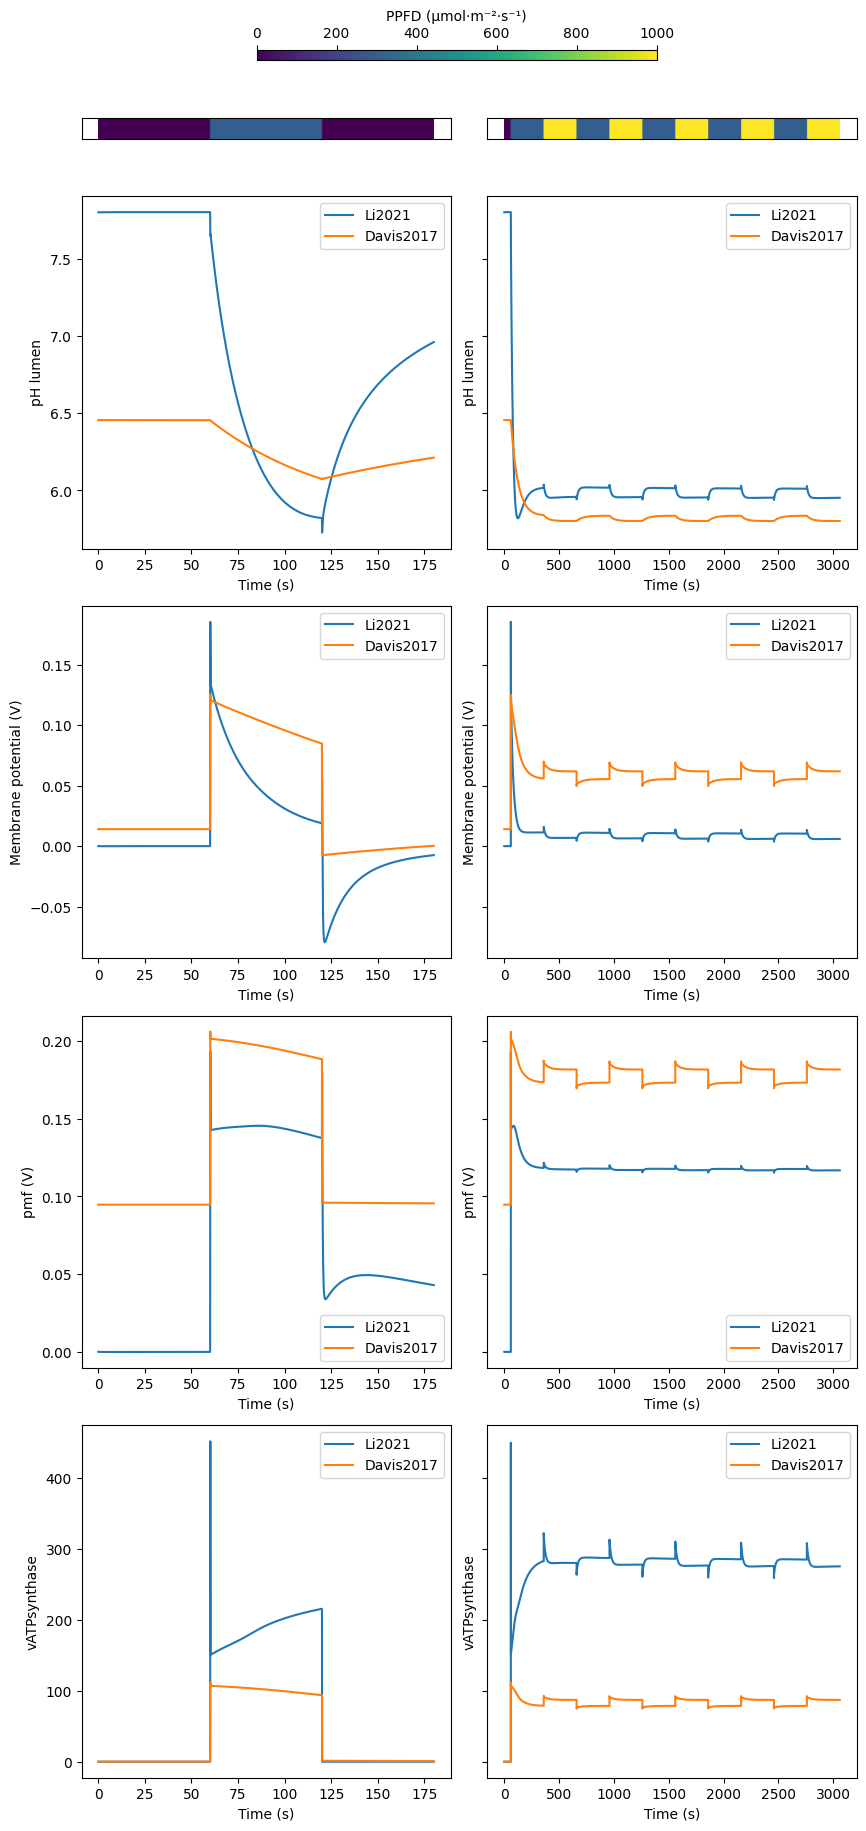

In [286]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable


PPFD_CMAP = "viridis" 
PPFD_NORM = Normalize(vmin=0, vmax=1000)

plot_list_davis = ["pH_lumen", "Dpsi", "pmf", "vATPsynthase"]
plot_list_li = ["pH_lumen", "Dpsi", "pmf", "v_pmf_protons_activity"]
Label = ["pH lumen", "Membrane potential (V)", "pmf (V)", "vATPsynthase"]
ncols = 2
nrows = 4
strip_height_ratio = 0.06
fig, axes = plt.subplots(
    nrows + 1, ncols, figsize=(10, 20),
    gridspec_kw={'height_ratios': [strip_height_ratio] + [1]*nrows,
                 'hspace': 0.2, 'wspace': 0.1},
    sharey='row',
)

fig.subplots_adjust(top=0.94)   # reserve blank space at the top of the whole figure
cbar_ax = fig.add_axes([0.3, 0.965, 0.4, 0.01]) 

margin_frac=0.05

row_first_ax = {}
for c, prot, li_dat, davis_dat in zip(range(ncols), [protocol, protocol_long], [li, li_long], [norm, norm_long]):
    axbar = axes[0, c]
    t_min = prot.index[0].total_seconds()
    t_max = prot.index[-1].total_seconds()
    pad = margin_frac * (t_max- t_min) 
    periods = prot.index.total_seconds().to_series().diff()
    periods.iloc[0] = prot.index.total_seconds()[0] 
    array = [ [light]*int(time) for  time, light in zip(periods, prot.values.flatten()) ]
    axbar.imshow(np.concatenate(array).reshape(1, -1), 
                 cmap=PPFD_CMAP, norm=PPFD_NORM,
                 aspect="auto", extent=[t_min, t_max, 0, 1])
    axbar.set_xlim(t_min - pad, t_max + pad) 
    axbar.set_xticks([])
    axbar.set_yticks([])
    for r, par_davis, par_li, label in zip(range(nrows),plot_list_davis, plot_list_li, Label):
        ax = axes[r + 1,c]
        ax.plot(li_dat[par_li], label = "Li2021")
        ax.plot(davis_dat[par_davis], label = "Davis2017")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(label)
        ax.legend()

# colorbar goes AFTER the loop, referencing the same fig/axes you just filled
sm = ScalarMappable(norm=PPFD_NORM, cmap=PPFD_CMAP)
sm.set_array([])
cbar = fig.colorbar(sm, ax=cbar_ax, orientation='horizontal',
                     fraction=0.6, aspect=40, pad=0.5, location='top')
cbar.set_label('PPFD (µmol·m⁻²·s⁻¹)')
cbar_ax.set_axis_off()


In [ ]:
protocol.diff()

TimedeltaIndex([NaT, '0 days 00:01:00', '0 days 00:01:00'], dtype='timedelta64[ns]', name='Timedelta', freq=None)

In [ ]:
array = [ [light]*int(time) for  time, light in zip(protocol.index.total_seconds(), protocol.values.flatten()) ]

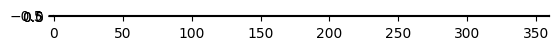

In [266]:
plt.imshow(np.array([array[0]+array[1]+array[2]]))

In [265]:
np.array([array[0]+array[1]+array[2]])

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

In [240]:
prot.index[-1].total_seconds()

3060.0

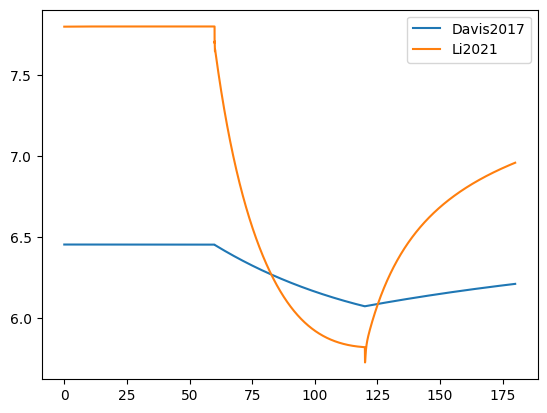

In [234]:
plt.plot(norm["pH_lumen"], label = "Davis2017")
plt.plot(li["pH_lumen"], label = "Li2021")
# plt.plot(matu["pH_lu"], label = "Matuszynska2016")
plt.legend()

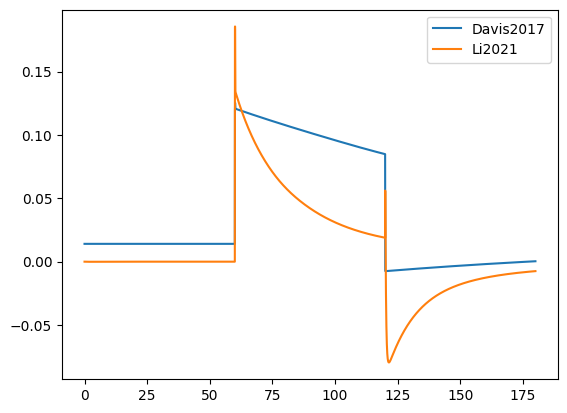

In [235]:
plt.plot(norm["Dpsi"], label = "Davis2017")
plt.plot(li["Dpsi"], label = "Li2021")
plt.legend()

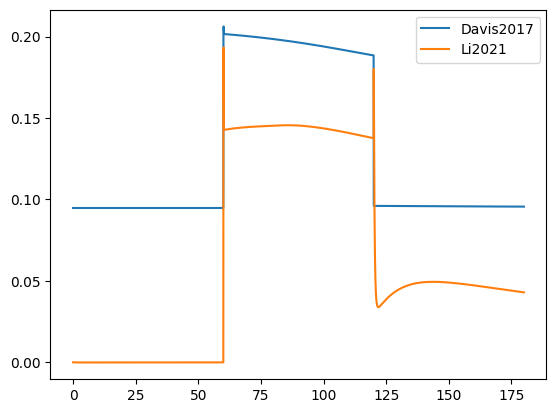

In [236]:
plt.plot(norm["pmf"], label = "Davis2017")
plt.plot(li["pmf"], label = "Li2021")
plt.legend()

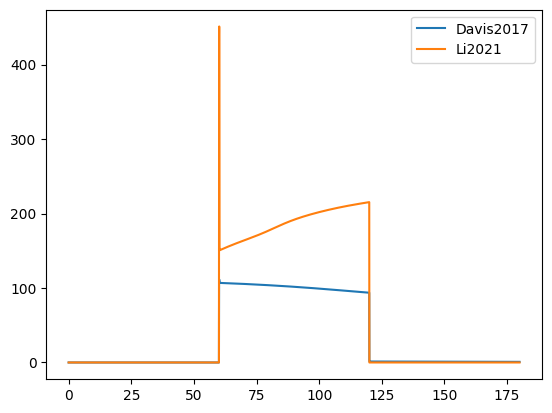

In [237]:
plt.plot(norm["vATPsynthase"], label = "Davis2017")
plt.plot(li["v_pmf_protons_activity"], label = "Li2021")
plt.legend()